In [1]:
#DRMD old pantheon vs new pantheon 

import numpy as np
import arviz as az
import matplotlib.pyplot as plt
from getdist import loadMCSamples, plots


# ==============================
# 1. FILE ROOTS (EDIT THESE)
# ==============================

file_root_1 = "/home/jthybo/connect_public/resources/montepython_public/chains/DRMD_final_planck_lite/2026-04-02_2000000_"
file_root_2 = "/home/jthybo/connect_public/resources/montepython_public/chains/DRMD_final_planck_lite_old_pantheon/2026-04-08_2000000_"


# ==============================
# 2. LOAD SAMPLES
# ==============================

samples1 = loadMCSamples(file_root_1, settings={'ignore_rows': 0.3})
samples2 = loadMCSamples(file_root_2)




=== New pantheon ===
Parameter                      | R-1         
---------------------------------------------
omega_b                        | 0.073592
omega_cdm                      | 1.170977
h                              | 0.108858
ln10^{10}A_s                   | 0.018975
n_s                            | 0.007052
tau_reio                       | 0.049150
delta_Neff_drmd                | 0.750835
log10z_stop                    | 0.047400
f_idm_drmd                     | 0.188406
log10_G_over_aH_drmd           | 0.001043
A_planck                       | 0.001553
M                              | 2.342560
H0                             | 0.107797
Omega_m                        | 0.167281
sigma8                         | 0.016258
rs_d                           | 1.111646
YHe                            | 0.068756
z_reio                         | 0.033687
Omega_Lambda                   | 0.166412
100theta_s                     | 0.124579
f_drmd                         | 0.750644
z_de

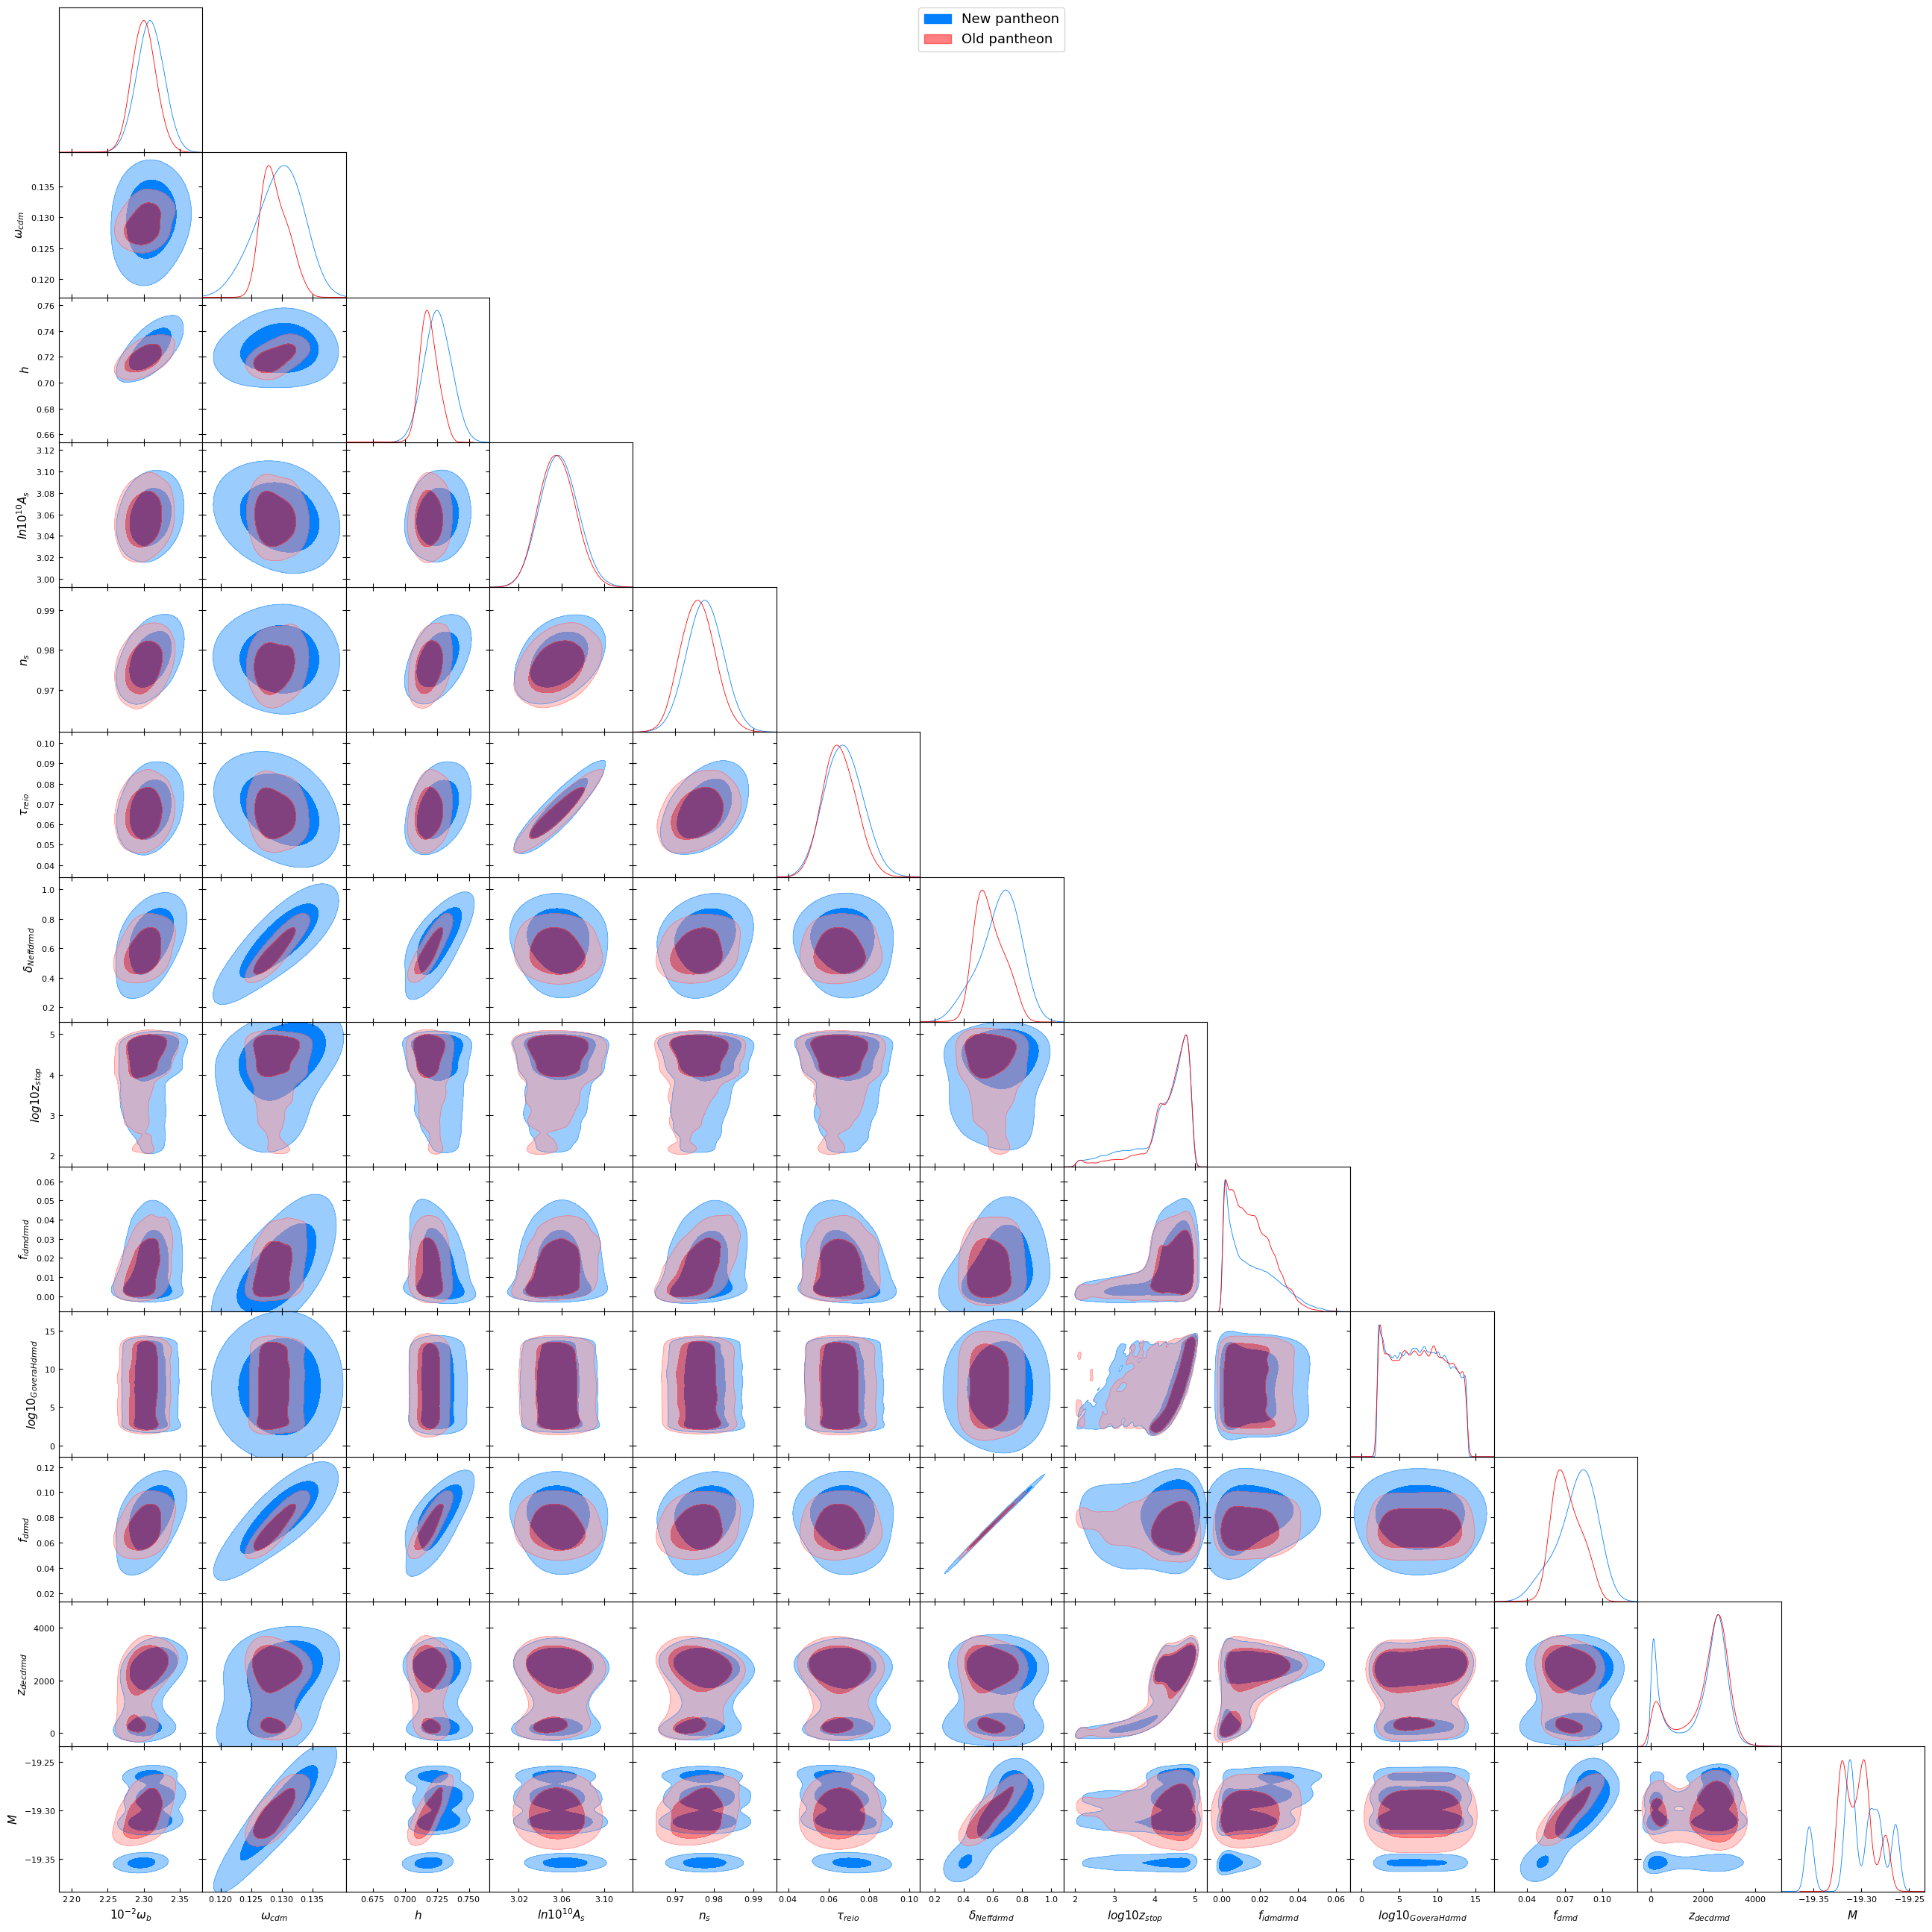

In [2]:
# ==============================
# 3. FUNCTION: COMPUTE R-1
# ==============================

def compute_r_minus_1(samples, label="Run"):
    chains = samples.getSeparateChains()
    param_names = samples.getParamNames().list()

    # Truncate to shortest chain
    min_len = min(chain.samples.shape[0] for chain in chains)
    chain_array = np.array([
        chain.samples[:min_len, :] for chain in chains
    ])  # (nchains, nsamples, nparams)

    # Build dict for ArviZ
    posterior_dict = {
        name: chain_array[:, :, i]
        for i, name in enumerate(param_names)
    }

    # Convert to InferenceData
    idata = az.from_dict({"posterior": posterior_dict})

    # Compute R-hat
    rhat = az.rhat(idata)

    # Print results
    print(f"\n=== {label} ===")
    print(f"{'Parameter':<30} | {'R-1':<12}")
    print("-" * 45)

    max_r_minus_1 = 0.0
    for name in param_names:
        r_minus_1 = float(rhat[name].values - 1.0)
        max_r_minus_1 = max(max_r_minus_1, r_minus_1)
        print(f"{name:<30} | {r_minus_1:.6f}")

    print("-" * 45)
    print(f"Max Gelman-Rubin (R-1): {max_r_minus_1:.6f}")

    return max_r_minus_1


# ==============================
# 4. COMPUTE R-1 FOR BOTH
# ==============================

compute_r_minus_1(samples1, label="New pantheon")
compute_r_minus_1(samples2, label="Old pantheon")


# ==============================
# 5. PARAMETERS TO PLOT
# ==============================

params_to_plot = [
    "omega_b",
    "omega_cdm",
    "h",
    "ln10^{10}A_s",
    "n_s",
    "tau_reio",
    "delta_Neff_drmd",
    "log10z_stop",
    "f_idm_drmd",
    "log10_G_over_aH_drmd",
    "f_drmd",
    "z_dec_drmd",
    "M"
]


# ==============================
# 6. TRIANGLE PLOT (COMPARISON)
# ==============================

g = plots.get_subplot_plotter()
g.settings.alpha_filled_add = 0.5   # lower = more transparent
g.settings.legend_fontsize = 16  # 👈 this is the one you want
g.triangle_plot(
    [samples1, samples2],   # <-- KEY CHANGE
    params=params_to_plot,
    filled=True,
    legend_labels=["New pantheon", "Old pantheon"],
    contour_colors = ["#0480fc","#FF0303"]

)

plt.show()